
========== IMPORTING LIBRARIES ==========


========== LOADING DATASET ==========

Dataset Shape: (381109, 12)
   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                

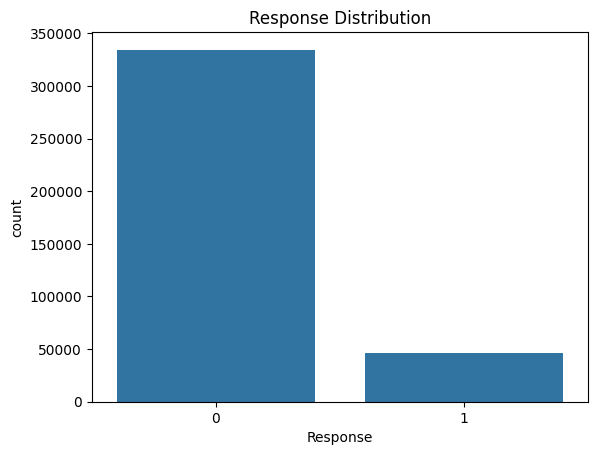


========== DATA PREPROCESSING ==========


========== FEATURE SCALING ==========


========== TRAIN TEST SPLIT ==========

Training Shape: (285831, 11)
Testing Shape: (95278, 11)

========== FINAL MODEL TRAINING ==========

Model Training Completed Successfully ✅

========== MODEL EVALUATION ==========

              precision    recall  f1-score   support

           0       0.99      0.66      0.79     83513
           1       0.28      0.94      0.43     11765

    accuracy                           0.70     95278
   macro avg       0.63      0.80      0.61     95278
weighted avg       0.90      0.70      0.75     95278


========== SAVING MODEL ==========

Model saved successfully ✅

========== LOADING SAVED MODEL ==========

Model loaded successfully ✅

========== FEATURE IMPORTANCE ==========



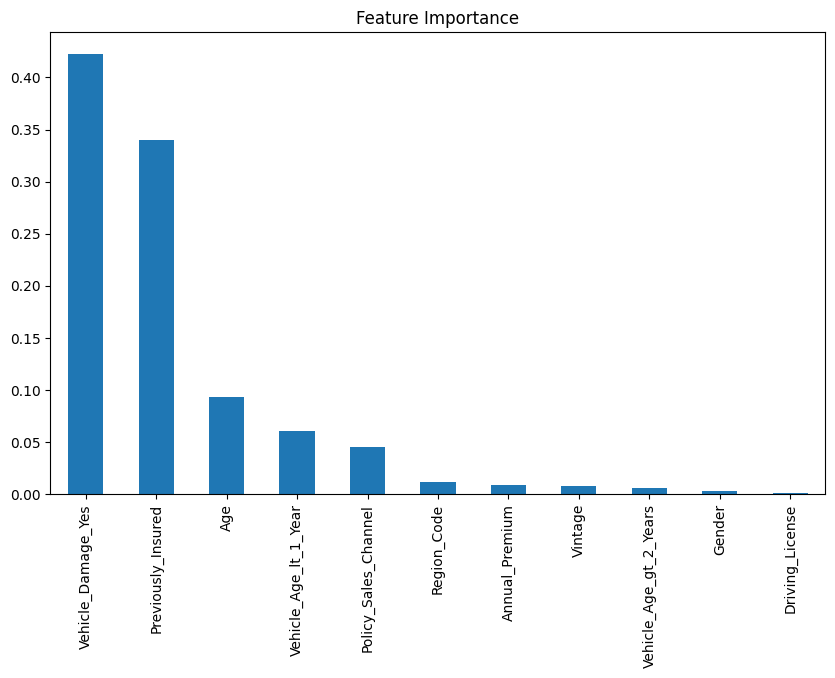


========== PIPELINE COMPLETED SUCCESSFULLY ==========



In [4]:
############################################################
# VEHICLE INSURANCE RESPONSE PREDICTION - RANDOM FOREST MODEL
############################################################

"""
Goal:
Predict whether a customer is interested in vehicle insurance.

Response = Target Variable
1 -> Interested
0 -> Not Interested
"""

############################################################
# IMPORT LIBRARIES
############################################################

print("\n========== IMPORTING LIBRARIES ==========\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

############################################################
# LOAD DATASET
############################################################

print("\n========== LOADING DATASET ==========\n")

df = pd.read_csv("data.csv")  # change path if needed

print("Dataset Shape:", df.shape)
print(df.head())

############################################################
# DATASET BASIC INFORMATION
############################################################

print("\n========== DATASET INFO ==========\n")

print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

############################################################
# TARGET VARIABLE DISTRIBUTION
############################################################

print("\n========== TARGET DISTRIBUTION ==========\n")

print(df['Response'].value_counts())

sns.countplot(x='Response', data=df)
plt.title("Response Distribution")
plt.show()

############################################################
# DATA PREPROCESSING
############################################################

print("\n========== DATA PREPROCESSING ==========\n")

# Encode Gender column
df['Gender'] = df['Gender'].map({
    'Female': 0,
    'Male': 1
}).astype(int)

# Convert categorical columns into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Rename columns
df.rename(columns={
    "Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year",
    "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"
}, inplace=True)

# Convert boolean columns to integer
df['Vehicle_Age_lt_1_Year'] = df['Vehicle_Age_lt_1_Year'].astype(int)
df['Vehicle_Age_gt_2_Years'] = df['Vehicle_Age_gt_2_Years'].astype(int)
df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype(int)

############################################################
# FEATURE SCALING
############################################################

print("\n========== FEATURE SCALING ==========\n")

num_features = ['Age', 'Vintage']

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

premium_scaler = MinMaxScaler()
df[['Annual_Premium']] = premium_scaler.fit_transform(
    df[['Annual_Premium']]
)

############################################################
# DROP ID COLUMN
############################################################

df.drop("id", axis=1, inplace=True)

############################################################
# TRAIN TEST SPLIT
############################################################

print("\n========== TRAIN TEST SPLIT ==========\n")

X = df.drop("Response", axis=1)
y = df["Response"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

############################################################
# FINAL RANDOM FOREST MODEL TRAINING (FAST VERSION)
############################################################

print("\n========== FINAL MODEL TRAINING ==========\n")

rf_model = RandomForestClassifier(

    n_estimators=300,
    min_samples_split=7,
    min_samples_leaf=4,
    max_depth=10,
    criterion='gini',

    class_weight="balanced",   # handles imbalance internally
    n_jobs=-1,                 # uses all CPU cores
    random_state=42

)

rf_model.fit(x_train, y_train)

print("Model Training Completed Successfully ✅")

############################################################
# MODEL EVALUATION
############################################################

print("\n========== MODEL EVALUATION ==========\n")

y_pred = rf_model.predict(x_test)

print(classification_report(y_test, y_pred))

############################################################
# SAVE MODEL
############################################################

print("\n========== SAVING MODEL ==========\n")

filename = "rf_model.pkl"

pickle.dump(rf_model, open(filename, "wb"))

print("Model saved successfully ✅")

############################################################
# LOAD MODEL AGAIN
############################################################

print("\n========== LOADING SAVED MODEL ==========\n")

loaded_model = pickle.load(open(filename, "rb"))

print("Model loaded successfully ✅")

############################################################
# FEATURE IMPORTANCE VISUALIZATION
############################################################

print("\n========== FEATURE IMPORTANCE ==========\n")

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.plot(kind='bar')

plt.title("Feature Importance")

plt.show()

############################################################
# FINAL MESSAGE
############################################################

print("\n========== PIPELINE COMPLETED SUCCESSFULLY ==========\n")